# Atividade 5 - Análise Exploratória do Titanic
Neste notebook, vamos analisar o dataset `train.csv` para entender o perfil dos passageiros e as taxas de sobrevivência.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregando o arquivo
df = pd.read_csv('train.csv')
display(df.head()) 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Estrutura e Tipos de Dados
Vamos verificar a quantidade de linhas e colunas, além dos tipos de variáveis presentes no dataset.

In [4]:
print(f"O dataset possui {df.shape[0]} linhas e {df.shape[1]} colunas.\n")

print("Tipos de dado de cada variável:")
display(df.dtypes)

O dataset possui 891 linhas e 12 colunas.

Tipos de dado de cada variável:


PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

## 2. Resumo Estatístico
Abaixo, o resumo estatístico das variáveis numéricas e categóricas.

In [5]:
display(df.describe(include='all'))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


## 3. Análise de Sobrevivência
Quantidade de pessoas que sobreviveram ao naufrágio. O gráfico de barras foi escolhido para comparar as contagens de categorias (Sobreviveu x Não Sobreviveu).

Survived
0    549
1    342
Name: count, dtype: int64

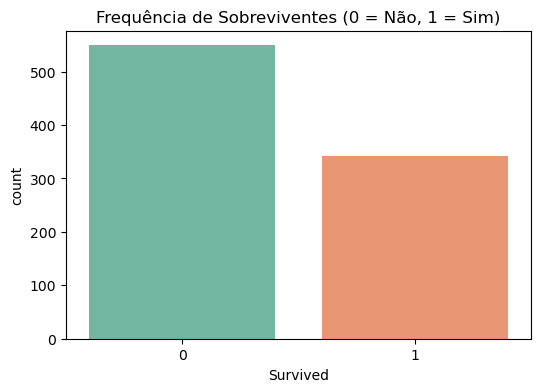

In [7]:
display(df['Survived'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Survived', hue='Survived', palette='Set2', legend=False)
plt.title('Frequência de Sobreviventes (0 = Não, 1 = Sim)')
plt.show()

## 4. Sobrevivência por Sexo e Classe Mais Frequente
Nesta etapa, vamos cruzar as informações de gênero com a taxa de sobrevivência e descobrir qual era a classe com mais passageiros.

A classe mais frequente no navio era a 3ª Classe.

Relação entre Sexo e Sobrevivência:


Survived,0,1
Sex,,
female,81,233
male,468,109


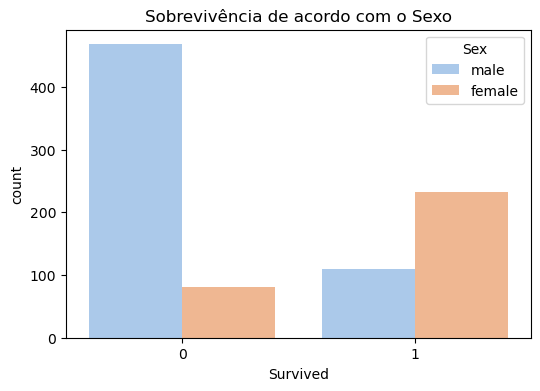

In [8]:
classe_frequente = df['Pclass'].mode()[0]
print(f"A classe mais frequente no navio era a {classe_frequente}ª Classe.\n")

print("Relação entre Sexo e Sobrevivência:")
tabela_sexo = pd.crosstab(df['Sex'], df['Survived'])
display(tabela_sexo)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Survived', hue='Sex', palette='pastel')
plt.title('Sobrevivência de acordo com o Sexo')
plt.show()

## 5. Distribuição das Idades
Por fim, vamos analisar a faixa etária dos passageiros a bordo. A distribuição apresenta uma leve assimetria à direita, indicando que a grande maioria era jovem adulta (entre 20 e 35 anos).

plt.figure(figsize=(8, 5))
sns.histplot(df['Age'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Distribuição das Idades dos Passageiros')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()